# Universal Astana + Almaty apartment price model v2

## tl;dr

Executed held-out result: **log RMSE 0.1304**, approximately
**13.9% multiplicative error**, median
absolute percentage error **7.2%**,
and q10–q90 coverage **74.4%** on
**5,469 test rows**.

**Status: provisional.** Almaty scrape has incomplete room partitions; metrics are provisional. The notebook saves a candidate bundle only and
does not replace the production Astana model.

## Context & Methods

The target is the natural logarithm of listing price per square metre.
The feature set is shared across cities and uses city-qualified districts
and residential complexes, H3 cells, building/apartment attributes, and
distances and local counts for eight OpenStreetMap POI categories.

To reduce leakage from duplicated or reposted apartments, split assignment
is based on a stable hash of a property-like group (city, H3 cell, ЖК,
rooms, area, floors, and construction year). All rows in the same group
remain in the same train/validation/test partition. The Almaty notebook
uses the exact same split rule, which makes its test rows directly
comparable with the Almaty slice of the universal notebook.

### Key Assumptions

- Krisha asking prices are treated as market signals, not completed sale prices.
- Rows outside 100,000–5,000,000 KZT/m² are removed as likely input errors or
  out-of-domain luxury/special cases.
- OSM distances are straight-line distances to representative POI points,
  not walking or driving routes.
- `listing_url`, scrape timestamps, and scrape partitions are audit fields;
  they never enter CatBoost.
- Candidate models are not production-ready while the Almaty room partitions
  are incomplete.

In [1]:
from pathlib import Path
import hashlib
import json
import subprocess
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from catboost import CatBoostRegressor
from IPython.display import display, Markdown
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")

def find_repo_root(start: Path) -> Path:
    for candidate in [start.resolve(), *start.resolve().parents]:
        if (candidate / "app" / "feature_pipeline_v2.py").exists():
            return candidate
    raise FileNotFoundError("Run this notebook from inside the repository.")

ROOT = find_repo_root(Path.cwd())
DATA_PATH = ROOT / "data" / "universal_training_v2.csv"
METADATA_PATH = ROOT / "models_candidate" / "universal_v2_model_metadata.json"
SCRAPE_STATE_PATH = ROOT / "data" / "almaty_sale_raw.state.json"
OUTPUT_DIR = ROOT / "models_candidate" / "universal_v2" / "notebook_baseline"

SCOPE = "universal"
RANDOM_SEED = 42
PRICE_PER_M2_MIN = 100_000
PRICE_PER_M2_MAX = 5_000_000
ITERATIONS = 500
DEPTH = 7
LEARNING_RATE = 0.05
EARLY_STOPPING_ROUNDS = 75
SAVE_CANDIDATE_MODELS = True
REBUILD_DATASET = False

print(f"Repository: {ROOT}")
print(f"Scope: {SCOPE}")

Repository: C:\Users\kaira\OneDrive\Documents\KrishaListings\Pet-projects
Scope: universal


## Data

In [2]:
if REBUILD_DATASET:
    command = [
        sys.executable,
        str(ROOT / "scripts" / "build_universal_dataset.py"),
        "--input", str(ROOT / "krisha_data_raw_orig.csv"),
        "--input", str(ROOT / "krisha_data_raw.csv"),
        "--input", str(ROOT / "data" / "almaty_sale_raw.csv"),
    ]
    subprocess.run(command, cwd=ROOT, check=True)

if not DATA_PATH.exists() or not METADATA_PATH.exists():
    raise FileNotFoundError(
        "Build data/universal_training_v2.csv first; see DATA.md."
    )

df_all = pd.read_csv(DATA_PATH, low_memory=False)
metadata = json.loads(METADATA_PATH.read_text(encoding="utf-8"))
feature_columns = metadata["feature_columns"]
categorical_features = metadata["categorical_features"]
target_column = metadata["target"]

missing_features = sorted(set(feature_columns) - set(df_all.columns))
if missing_features:
    raise ValueError(f"Dataset is missing model features: {missing_features}")

price_per_m2 = np.exp(pd.to_numeric(df_all[target_column], errors="coerce"))
domain_mask = price_per_m2.between(PRICE_PER_M2_MIN, PRICE_PER_M2_MAX)
removed_outliers = int((~domain_mask).sum())
df = df_all.loc[domain_mask].copy()
if SCOPE == "almaty":
    df = df.loc[df["city"].eq("almaty")].copy()

state = {}
if SCRAPE_STATE_PATH.exists():
    state = json.loads(SCRAPE_STATE_PATH.read_text(encoding="utf-8"))
partitions = state.get("partitions", {})
almaty_inventory_complete = bool(partitions) and all(
    item.get("complete", False) for item in partitions.values()
)

display(Markdown(
    "✅ Almaty collector reports all room partitions complete."
    if almaty_inventory_complete
    else "⚠️ **Provisional dataset:** Almaty room partitions are incomplete. "
         "Do not promote these models to production yet."
))
print(f"Rows loaded: {len(df_all):,}")
print(f"Out-of-domain rows removed globally: {removed_outliers:,}")
print(f"Rows in notebook scope: {len(df):,}")
display(df.groupby(["city", "rooms"], dropna=False).size().rename("rows").to_frame())

⚠️ **Provisional dataset:** Almaty room partitions are incomplete. Do not promote these models to production yet.

Rows loaded: 36,070
Out-of-domain rows removed globally: 3
Rows in notebook scope: 36,067


rows
city   rooms        
almaty 1.000   10828
       2.000    9103
       3.000      61
astana 1.000    4113
       2.000    6277
       3.000    4153
       4.000    1275
       5.000     203
       6.000      33
       7.000      12
       8.000       8
       17.000      1

In [3]:
audit_columns = [column for column in [
    "listing_url", "scraped_at", "scrape_partition"
] if column in df.columns]
quality = pd.DataFrame({
    "missing_pct": df[feature_columns].isna().mean().mul(100),
    "unique_values": df[feature_columns].nunique(dropna=True),
}).sort_values("missing_pct", ascending=False)

print(f"Unique listing URLs: {df['listing_url'].nunique():,}" if "listing_url" in df else "No URL audit column")
print(f"Audit fields excluded from the model: {audit_columns}")
display(quality.head(15))

Unique listing URLs: 36,067
Audit fields excluded from the model: ['listing_url', 'scraped_at', 'scrape_partition']


,missing_pct,unique_values
ceiling_height,15.571,81
current_floor,5.770,34
total_floors,5.770,44
floor_ratio,5.770,246
city,0.000,2
count_mall_within_2km,0.000,23
count_kindergarten_within_500m,0.000,9
count_kindergarten_within_1km,0.000,14
count_kindergarten_within_2km,0.000,31
dist_to_nearest_grocery_km,0.000,19940


In [4]:
def normalized_token(series: pd.Series) -> pd.Series:
    return series.fillna("__missing__").astype(str).str.strip().str.lower()

def rounded_token(series: pd.Series, decimals: int = 1) -> pd.Series:
    values = pd.to_numeric(series, errors="coerce").round(decimals)
    return values.fillna(-999999).astype(str)

group_parts = [
    normalized_token(df["city"]),
    normalized_token(df["h3_res_9"]),
    normalized_token(df["city_residential_complex"]),
    rounded_token(df["rooms"], 0),
    rounded_token(df["area_m2"], 1),
    rounded_token(df["current_floor"], 0),
    rounded_token(df["total_floors"], 0),
    rounded_token(df["year_of_construction"], 0),
]
property_group = group_parts[0]
for part in group_parts[1:]:
    property_group = property_group.str.cat(part, sep="|")

buckets = property_group.map(
    lambda value: int(hashlib.sha256(value.encode("utf-8")).hexdigest()[:8], 16) % 100
)
df["split"] = np.select(
    [buckets.lt(70), buckets.lt(85)], ["train", "validation"], default="test"
)
df["property_group"] = property_group

leakage_check = df.groupby("property_group")["split"].nunique().max()
assert leakage_check == 1, "A property-like group crossed split boundaries."
split_summary = df.groupby(["split", "city"]).size().unstack(fill_value=0)
display(split_summary)

city,almaty,astana
split,,
test,3104,2365
train,13922,11373
validation,2966,2337


## Results

In [5]:
for column in categorical_features:
    df[column] = df[column].fillna("__missing__").astype(str)
numeric_features = [column for column in feature_columns if column not in categorical_features]
for column in numeric_features:
    df[column] = pd.to_numeric(df[column], errors="coerce")

subsets = {name: df.loc[df["split"].eq(name)].copy() for name in ["train", "validation", "test"]}
if min(len(part) for part in subsets.values()) == 0:
    raise ValueError("At least one split is empty.")

X = {name: part[feature_columns] for name, part in subsets.items()}
y = {name: pd.to_numeric(part[target_column], errors="raise") for name, part in subsets.items()}
cat_indices = [feature_columns.index(column) for column in categorical_features]

quantile_alphas = {"q10": 0.10, "q50": 0.50, "q90": 0.90}
models = {}
predictions = {}

for label, alpha in quantile_alphas.items():
    print(f"Training {label}...")
    model = CatBoostRegressor(
        loss_function=f"Quantile:alpha={alpha}",
        eval_metric=f"Quantile:alpha={alpha}",
        iterations=ITERATIONS,
        depth=DEPTH,
        learning_rate=LEARNING_RATE,
        random_seed=RANDOM_SEED,
        l2_leaf_reg=5,
        random_strength=0.5,
        verbose=100,
        allow_writing_files=False,
        thread_count=-1,
    )
    model.fit(
        X["train"], y["train"],
        cat_features=cat_indices,
        eval_set=(X["validation"], y["validation"]),
        early_stopping_rounds=EARLY_STOPPING_ROUNDS,
        use_best_model=True,
    )
    models[label] = model
    predictions[label] = model.predict(X["test"])

Training q10...


0:	learn: 0.0492518	test: 0.0494651	best: 0.0494651 (0)	total: 222ms	remaining: 1m 50s


100:	learn: 0.0235130	test: 0.0240939	best: 0.0240939 (100)	total: 8.85s	remaining: 35s


200:	learn: 0.0211819	test: 0.0224800	best: 0.0224800 (200)	total: 17.5s	remaining: 26.1s


300:	learn: 0.0198466	test: 0.0218333	best: 0.0218318 (299)	total: 26.4s	remaining: 17.4s


...

100:	learn: 0.0242576	test: 0.0245340	best: 0.0245340 (100)	total: 8.35s	remaining: 33s


200:	learn: 0.0220400	test: 0.0232090	best: 0.0232090 (200)	total: 16.7s	remaining: 24.8s


300:	learn: 0.0210093	test: 0.0228510	best: 0.0228510 (300)	total: 24.9s	remaining: 16.5s


400:	learn: 0.0206501	test: 0.0227553	best: 0.0227522 (393)	total: 33.3s	remaining: 8.21s


Stopped by overfitting detector  (75 iterations wait)

bestTest = 0.02275170827
bestIteration = 422

Shrink model to first 423 iterations.


In [6]:
def regression_metrics(actual_log, pred_log, pred_low=None, pred_high=None):
    actual_log = np.asarray(actual_log)
    pred_log = np.asarray(pred_log)
    actual = np.exp(actual_log)
    predicted = np.exp(pred_log)
    log_rmse = float(np.sqrt(mean_squared_error(actual_log, pred_log)))
    result = {
        "rows": int(len(actual_log)),
        "log_rmse": log_rmse,
        "approx_multiplicative_error_pct": float(np.expm1(log_rmse) * 100),
        "log_mae": float(mean_absolute_error(actual_log, pred_log)),
        "log_r2": float(r2_score(actual_log, pred_log)),
        "mae_kzt_per_m2": float(mean_absolute_error(actual, predicted)),
        "rmse_kzt_per_m2": float(np.sqrt(mean_squared_error(actual, predicted))),
        "median_absolute_percentage_error_pct": float(
            np.median(np.abs(predicted - actual) / actual) * 100
        ),
    }
    if pred_low is not None and pred_high is not None:
        result["q10_q90_coverage_pct"] = float(
            np.mean((actual_log >= pred_low) & (actual_log <= pred_high)) * 100
        )
        result["bad_quantile_order_pct"] = float(
            np.mean((pred_low > pred_log) | (pred_log > pred_high)) * 100
        )
    return result

overall_metrics = regression_metrics(
    y["test"], predictions["q50"], predictions["q10"], predictions["q90"]
)
display(pd.DataFrame([overall_metrics], index=["test_overall"]).T)

test_results = subsets["test"][["city", "rooms", "listing_url"]].reset_index(drop=True)
test_results["actual_log"] = y["test"].to_numpy()
for label, values in predictions.items():
    test_results[f"pred_{label}_log"] = values

segment_rows = []
segment_column = "city" if SCOPE == "universal" else "rooms"
for segment, part in test_results.groupby(segment_column):
    if len(part) < 30:
        continue
    values = regression_metrics(
        part["actual_log"], part["pred_q50_log"],
        part["pred_q10_log"], part["pred_q90_log"],
    )
    values["segment"] = segment
    segment_rows.append(values)
segment_metrics = pd.DataFrame(segment_rows).set_index("segment") if segment_rows else pd.DataFrame()
display(segment_metrics)

,test_overall
rows,"5,469.000"
log_rmse,0.130
approx_multiplicative_error_pct,13.933
log_mae,0.095
log_r2,0.798
mae_kzt_per_m2,"68,950.144"
rmse_kzt_per_m2,"104,897.543"
median_absolute_percentage_error_pct,7.205
q10_q90_coverage_pct,74.438
bad_quantile_order_pct,0.018


,rows,log_rmse,approx_multiplicative_error_pct,log_mae,log_r2,mae_kzt_per_m2,rmse_kzt_per_m2,median_absolute_percentage_error_pct,q10_q90_coverage_pct,bad_quantile_order_pct
segment,,,,,,,,,,
almaty,3104,0.125,13.281,0.089,0.772,"70,246.497","108,562.265",6.858,73.711,0.000
astana,2365,0.138,14.752,0.102,0.785,"67,248.716","99,883.857",7.696,75.391,0.042


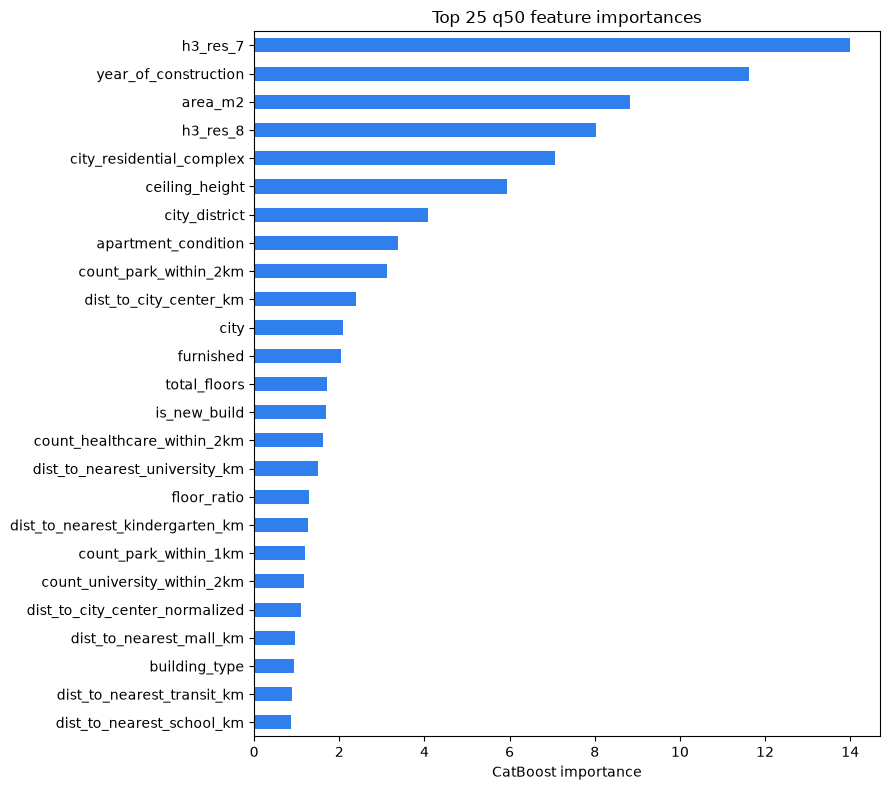

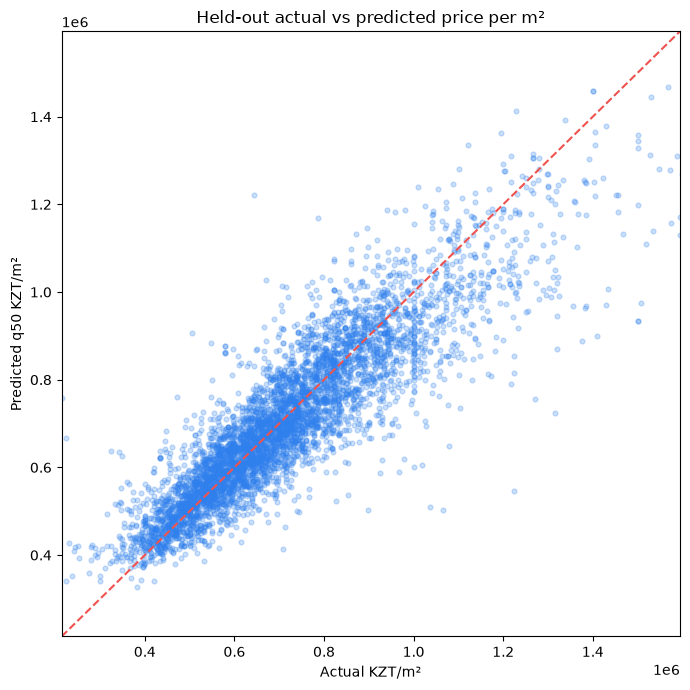

In [7]:
importance = pd.Series(
    models["q50"].get_feature_importance(), index=feature_columns
).sort_values(ascending=False).head(25).sort_values()
ax = importance.plot.barh(figsize=(9, 8), color="#2f80ed")
ax.set_title("Top 25 q50 feature importances")
ax.set_xlabel("CatBoost importance")
plt.tight_layout()
plt.show()

actual = np.exp(test_results["actual_log"])
predicted = np.exp(test_results["pred_q50_log"])
lower = float(min(actual.min(), predicted.min()))
upper = float(max(actual.quantile(0.995), predicted.quantile(0.995)))
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(actual, predicted, s=12, alpha=0.25, color="#2f80ed")
ax.plot([lower, upper], [lower, upper], linestyle="--", color="#ef5350")
ax.set(xlim=(lower, upper), ylim=(lower, upper),
       xlabel="Actual KZT/m²", ylabel="Predicted q50 KZT/m²",
       title="Held-out actual vs predicted price per m²")
plt.tight_layout()
plt.show()

In [8]:
evaluation = {
    "scope": SCOPE,
    "production_ready": False,
    "data_inventory_complete": bool(almaty_inventory_complete),
    "warning": None if almaty_inventory_complete else (
        "Almaty scrape has incomplete room partitions; metrics are provisional."
    ),
    "dataset_path": str(DATA_PATH.relative_to(ROOT)),
    "rows_after_scope_and_filter": int(len(df)),
    "rows_by_split": {key: int(value) for key, value in df["split"].value_counts().items()},
    "price_per_m2_filter": [PRICE_PER_M2_MIN, PRICE_PER_M2_MAX],
    "split_definition": (
        "sha256(city|h3_res_9|city_residential_complex|rooms|area_m2|"
        "current_floor|total_floors|year_of_construction) modulo 100; "
        "0-69 train, 70-84 validation, 85-99 test"
    ),
    "parameters": {
        "iterations": ITERATIONS,
        "depth": DEPTH,
        "learning_rate": LEARNING_RATE,
        "early_stopping_rounds": EARLY_STOPPING_ROUNDS,
        "random_seed": RANDOM_SEED,
    },
    "best_iterations": {name: int(model.get_best_iteration()) for name, model in models.items()},
    "overall_test_metrics": overall_metrics,
    "segment_test_metrics": segment_metrics.reset_index().to_dict(orient="records"),
    "feature_columns": feature_columns,
    "categorical_features": categorical_features,
}

if SAVE_CANDIDATE_MODELS:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    for label, model in models.items():
        model.save_model(OUTPUT_DIR / f"model_{label}.cbm")
    (OUTPUT_DIR / "evaluation.json").write_text(
        json.dumps(evaluation, ensure_ascii=False, indent=2), encoding="utf-8"
    )
    print(f"Candidate bundle saved to: {OUTPUT_DIR}")

Candidate bundle saved to: C:\Users\kaira\OneDrive\Documents\KrishaListings\Pet-projects\models_candidate\universal_v2\notebook_baseline


## Takeaways

Use the held-out `log_rmse`, median percentage error, interval coverage,
and city/room slices together; no single metric is sufficient. A low
random-split score would not prove geographic or future-time
generalisation.

Before production promotion, finish all Almaty room partitions, rebuild
the shared dataset, rerun both notebooks, compare the Almaty rows on the
identical group-hash test split, and then run a later-scrape temporal
holdout. The notebook output is a candidate bundle only.